In [1]:
import pandas as pd


In [2]:
info={

   "Name":["harsh","Trisah","sanket"],
    "age":[21,21,20]
}

df=pd.DataFrame(info)
print(df)

     Name  age
0   harsh   21
1  Trisah   21
2  sanket   20


In [3]:
df

,Name,age
0,harsh,21
1,Trisah,21
2,sanket,20


In [4]:
#Series

df=[2,3,1,4,2]
print(df)

[2, 3, 1, 4, 2]


In [5]:
a=pd.Series(df,index=["a","b",3,"d","s"])
print(a.index)

Index(['a', 'b', 3, 'd', 's'], dtype='object')


In [6]:

a=pd.Series([1,2,3,4,5]);
b=pd.Series([10,20,30,40,50])


df=(a+b)
print(df)

0    11
1    22
2    33
3    44
4    55
dtype: int64


In [7]:
info={
    "name":["harsh","trisha","Utkarsh"],
    "age":[21,21,20]
}

# df=pd.DataFrame(info)
# print(df)

In [8]:
df

0    11
1    22
2    33
3    44
4    55
dtype: int64

In [9]:

df=pd.DataFrame(info,index=[11,22,33],columns=["a","b","c"])
print(df.index)
print(df.columns)


Index([11, 22, 33], dtype='int64')
Index(['a', 'b', 'c'], dtype='object')


In [10]:
#csv 
df=pd.read_csv("raw_data.csv")
print(df,type(df))

   Unnamed: 0.1  Unnamed: 0  id          name   age country   gender   income
0             0           9   4  Maria Garcia  34.0   Spain   Female      0.0
1             1           0   9   Carlos Ruiz   0.0  Mexico     Male  45000.0
2             2           1   3          Alex   0.0     USA  Unknown  47000.0
3             3           2   5        Li Wei  27.0   China     Male  51000.0
4             4           3   1      John Doe  29.0     USA     Male  55000.0
5             5           4  10   Emily Davis  31.0     USA        0  58000.0
6             6           5   2    Jane Smith   0.0  Canada   Female  62000.0
7             7           6   8    Rachel Lee  29.0     USA   Female  62000.0
8             8           7   7    Ahmed Khan  38.0       0     Male  68000.0
9             9           8   6             0  45.0   India   Female  73000.0 <class 'pandas.core.frame.DataFrame'>


In [11]:
# df=pd.read_json("employee_data.json")
# print(df,type(df))

In [12]:
df.head()
df.tail()
df.sample()
df.info();
df.describe()
df.shape
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  10 non-null     int64  
 1   Unnamed: 0    10 non-null     int64  
 2   id            10 non-null     int64  
 3   name          10 non-null     object 
 4   age           10 non-null     float64
 5   country       10 non-null     object 
 6   gender        10 non-null     object 
 7   income        10 non-null     float64
dtypes: float64(2), int64(3), object(3)
memory usage: 772.0+ bytes


Unnamed: 0.1    10
Unnamed: 0      10
id              10
name            10
age              7
country          7
gender           4
income           9
dtype: int64

In [13]:
# Feature Engineering
# Feature engineering means creating or transforming columns
# to make data more useful for analysis or Machine Learning.


# Create a copy of the original DataFrame
# This allows us to modify df2 without changing the original df
df2 = df.copy()


# Create a new "Tax" column based on income
# If income is >= 50,000 → Tax = "20%"
# If income is < 50,000 → Tax = "10%"
df2["Tax"] = df2["income"].apply(
    lambda x: "20%" if x >= 50000 else "10%"
)


# Create a dictionary to convert gender values
# Male → M
# Female → F
# Unknown → U
gender_value = {
    "Male": "M",
    "Female": "F",
    "Unknown": "U"
}


# Replace gender values using the dictionary
# .map() looks for each gender in gender_value
# and replaces it with the corresponding value
df2["gender"] = df2["gender"].map(gender_value)


# Create a new "new_income" column
# Increase the existing income by 10%
# Example: 50,000 → 55,000
df2 = df2.assign(
    new_income=df2["income"] * 1.1
)


# Replace "USA" with "United State" in the country column
df2["country"] = df2["country"].replace(
    "USA",
    "United State"
)


# Display the final DataFrame
df2

# 🔑 Main concepts you're learning
# Code	Purpose
# copy()	Create a separate DataFrame
# apply()	Apply a function to every value
# lambda	Create a small one-line function
# map()	Replace values using a dictionary
# assign()	Create a new column
# replace()	Replace specific values

,Unnamed: 0.1,Unnamed: 0,id,name,age,country,gender,income,Tax,new_income
0,0,9,4,Maria Garcia,34.0,Spain,F,0.0,10%,0.0
1,1,0,9,Carlos Ruiz,0.0,Mexico,M,45000.0,10%,49500.0
2,2,1,3,Alex,0.0,United State,U,47000.0,10%,51700.0
3,3,2,5,Li Wei,27.0,China,M,51000.0,20%,56100.0
4,4,3,1,John Doe,29.0,United State,M,55000.0,20%,60500.0
5,5,4,10,Emily Davis,31.0,United State,NaN,58000.0,20%,63800.0
6,6,5,2,Jane Smith,0.0,Canada,F,62000.0,20%,68200.0
7,7,6,8,Rachel Lee,29.0,United State,F,62000.0,20%,68200.0
8,8,7,7,Ahmed Khan,38.0,0,M,68000.0,20%,74800.0
9,9,8,6,0,45.0,India,F,73000.0,20%,80300.0


In [29]:
# Set / rename all column names of the DataFrame
# The number of names must match the number of columns
df2.columns = [
    "ID", "Name", "Age", "Country",
    "Gender", "Income", "Tax", "New_Income"
]


# Rename the "Income" column to "Salary"
# NOTE: This does NOT change df2 permanently unless we assign it back
df2.rename(columns={"Income": "Salary"})


# Replace all missing (NaN) values in the DataFrame with 50
df2 = df2.fillna(50)


# Sort the DataFrame according to the "Income" column
# By default, sorting is in ascending order (smallest → largest)
sorted_df2 = df2.sort_values("Income")


# Sort the DataFrame according to its index
# The original row index determines the order
sorted_df2.sort_index()


# Reset the index of the DataFrame
# This creates a new index starting from 0
# The old index is kept as a new column
# sorted_df2.reset_index()


# Reset the index and remove the old index
# drop=True prevents the old index from becoming a new column
sorted_df2 = sorted_df2.reset_index(drop=True)


# Create a "Ranking" column based on Income
# Default ranking is ascending (lowest income gets Rank 1)
# sorted_df2["Ranking"] = sorted_df2["Income"].rank()


# Create a "Ranking" column based on Income
# ascending=True → lowest income gets Rank 1
# highest income gets the highest rank
sorted_df2["Ranking"] = sorted_df2["Income"].rank(ascending=True)


# Select and display only the required columns
sorted_df2[
    ["ID", "Name", "Age", "Country",
     "Gender", "Income", "New_Income", "Tax"]
]

,ID,Name,Age,Country,Gender,Income,New_Income,Tax
0,8,7,7,Ahmed Khan,38.0,0,68000.0,Male
1,6,5,2,Jane Smith,0.0,Canada,62000.0,Female
2,3,2,5,Li Wei,27.0,China,51000.0,Male
3,9,8,6,0,45.0,India,73000.0,Female
4,1,0,9,Carlos Ruiz,0.0,Mexico,45000.0,Male
5,0,9,4,Maria Garcia,34.0,Spain,0.0,Female
6,2,1,3,Alex,0.0,USA,47000.0,Unknown
7,4,3,1,John Doe,29.0,USA,55000.0,Male
8,5,4,10,Emily Davis,31.0,USA,58000.0,0
9,7,6,8,Rachel Lee,29.0,USA,62000.0,Female


In [ ]:
# Create a copy of the original DataFrame
# This allows us to work with df2 without changing the original df
df2 = df.copy()


# Create a new list of column names using list comprehension
# Take every column from df2 except "id"
# Then add "id" at the end of the list
scroll = [col for col in df2.columns if col != "id"] + ["id"]


# Display the new column order
print(scroll)


# Reorder the DataFrame columns using the "scroll" list
# "id" will now appear as the last column
df2[scroll]

In [ ]:
# Create a copy of the original DataFrame
df2 = df.copy()


# Remove duplicate rows from the DataFrame
df2 = df2.drop_duplicates()


# Sort the DataFrame by the "income" column
# By default, sorting is done in ascending order
df2 = df2.sort_values("income")


# Replace all missing values (NaN) with 0
df2 = df2.fillna(0)


# Reset the DataFrame index after sorting
# drop=True removes the old index instead of keeping it as a new column
df2 = df2.reset_index(drop=True)


# Save the cleaned DataFrame to a CSV file
# The file will be created as "raw_data.csv"
df2.to_csv("raw_data.csv")

In [15]:
df2

,Unnamed: 0.1,Unnamed: 0,id,name,age,country,gender,income,Tax,new_income
0,0,9,4,Maria Garcia,34.0,Spain,F,0.0,10%,0.0
1,1,0,9,Carlos Ruiz,0.0,Mexico,M,45000.0,10%,49500.0
2,2,1,3,Alex,0.0,United State,U,47000.0,10%,51700.0
3,3,2,5,Li Wei,27.0,China,M,51000.0,20%,56100.0
4,4,3,1,John Doe,29.0,United State,M,55000.0,20%,60500.0
5,5,4,10,Emily Davis,31.0,United State,NaN,58000.0,20%,63800.0
6,6,5,2,Jane Smith,0.0,Canada,F,62000.0,20%,68200.0
7,7,6,8,Rachel Lee,29.0,United State,F,62000.0,20%,68200.0
8,8,7,7,Ahmed Khan,38.0,0,M,68000.0,20%,74800.0
9,9,8,6,0,45.0,India,F,73000.0,20%,80300.0


In [16]:
# Create a copy of the original DataFrame
df2 = df.copy()


# Group the data by country and calculate
# the average (mean) income for each country
df2.groupby("country")["income"].mean();


# Group the data by gender and find
# the maximum income for each gender
df2.groupby("gender")["income"].max();


# Group the data by country and calculate
# multiple statistics for the income column:
# mean → average income
# max  → highest income
# min  → lowest income
df2.groupby("country")["income"].agg(["mean", "max", "min"]);


# Group the data by country and calculate statistics
# with custom names for the output columns
df2.groupby("country")["income"].agg(
    average_income="mean",
    maximum_income="max"
)


# Group the data by country and calculate
# the average age and average income for each country
df2.groupby("country").agg({
    "age": "mean",
    "income": "mean"
})

,age,income
country,,
0,38.00,68000.0
Canada,0.00,62000.0
China,27.00,51000.0
India,45.00,73000.0
Mexico,0.00,45000.0
Spain,34.00,0.0
USA,22.25,55500.0


In [24]:
df

,Unnamed: 0,id,name,age,country,gender,income
0,0,9,Carlos Ruiz,0.0,Mexico,Male,45000.0
1,1,3,Alex,0.0,USA,Unknown,47000.0
2,2,5,Li Wei,27.0,China,Male,51000.0
3,3,1,John Doe,29.0,USA,Male,55000.0
4,4,10,Emily Davis,31.0,USA,0,58000.0
5,5,2,Jane Smith,0.0,Canada,Female,62000.0
6,6,8,Rachel Lee,29.0,USA,Female,62000.0
7,7,7,Ahmed Khan,38.0,0,Male,68000.0
8,8,6,0,45.0,India,Female,73000.0
9,9,4,Maria Garcia,34.0,Spain,Female,0.0


In [28]:
# ============================
# Melt & Pivot in Pandas
# ============================

# Create a DataFrame containing country, year, sales, and profit data
df = pd.DataFrame({
    "country": ["USA", "USA", "India", "India"],
    "year": [2020, 2021, 2020, 2021],
    "sales": [100, 120, 90, 110],
    "profit": [20, 25, 18, 22]
})


# ============================
# MELT
# ============================

# Convert the DataFrame from wide format to long format
melt_frame = df.melt(
    
    # Columns that should remain unchanged
    id_vars=["country", "year"],
    
    # Columns that will be converted into rows
    value_vars=["sales", "profit"],
    
    # Name of the new column containing "sales" and "profit"
    var_name="Matrix",
    
    # Name of the new column containing their corresponding values
    value_name="value"
)


# Display the melted DataFrame
print(melt_frame)


# ============================
# PIVOT
# ============================

# Convert the long-format DataFrame back into a wider format
pivot_frame = melt_frame.pivot(
    
    # Columns used to identify each row
    index=["country", "year"],
    
    # Values in the "Matrix" column become new column names
    columns="Matrix",
    
    # Values from the "value" column fill the new columns
    values="value"
)

# Display the pivoted DataFrame
print(pivot_frame)

Matrix        profit  sales
country year               
India   2020      18     90
        2021      22    110
USA     2020      20    100
        2021      25    120

In [24]:
melt_frame

,country,year,Matrix,value
0,USA,2020,sales,100
1,USA,2021,sales,120
2,India,2020,sales,90
3,India,2021,sales,110
4,USA,2020,profit,20
5,USA,2021,profit,25
6,India,2020,profit,18
7,India,2021,profit,22


<Axes: xlabel='Age', ylabel='Salary'>

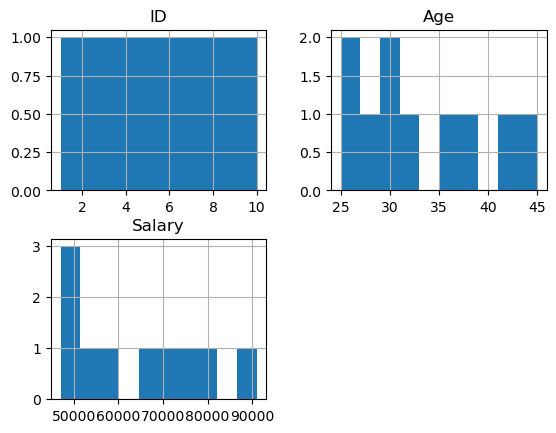

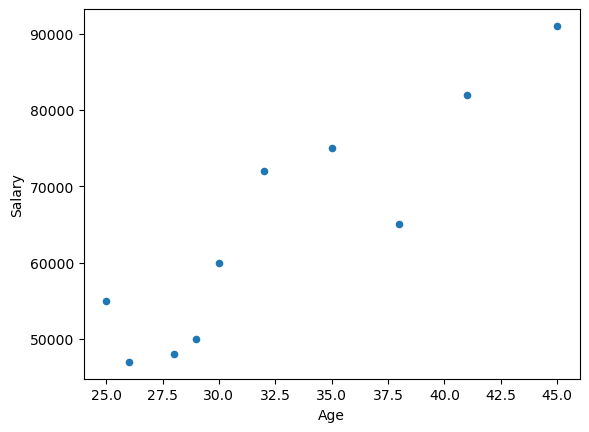

In [39]:
# Read the employee data from a CSV file
df = pd.read_csv("employee_data.csv")

# Create histograms for all numerical columns in the DataFrame
# Histograms show the distribution/frequency of numerical data
df.hist()

# Create a scatter plot to show the relationship between Age and Salary
# x-axis  → Age
# y-axis  → Salary
# Each point represents one employee
df.plot(kind="scatter", x="Age", y="Salary")

In [41]:
# ============================
# Merging & Joining in Pandas
# ============================

# Create a DataFrame containing customer information
df_customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "name": ["Adam", "Bob", "Charlie", "Dave"]
})

# Create a DataFrame containing order information
df_orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104],
    "customer_id": [2, 1, 4, 5],
    "amount": [250, 120, 300, 180]
})


# Inner Join:
# Returns only the rows where customer_id exists in BOTH DataFrames.
pd.merge(
    df_customers,
    df_orders,
    on="customer_id"
)


# Left Join:
# Returns ALL rows from df_customers.
# Matching order information is added where available.
# If no matching order exists, NaN is returned.
pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="left"
)


# Right Join:
# Returns ALL rows from df_orders.
# Matching customer information is added where available.
# If no matching customer exists, NaN is returned.
pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="right"
)


# Outer Join:
# Returns ALL rows from BOTH DataFrames.
# If there is no matching customer_id in one DataFrame,
# the missing values are filled with NaN.
pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="outer"
)

,customer_id,name,order_id,amount
0,2,Bob,101,250
1,1,Adam,102,120
2,4,Dave,103,300
3,5,NaN,104,180
